In [2]:
#Importing Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)



In [3]:
# Load Dataset

df = pd.read_csv("/content/car data.csv")

print("First 5 Rows")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())


First 5 Rows
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-nul

In [4]:
# Data Preprocessing
# Create Car Age Feature
current_year = 2025
df['Car_Age'] = current_year - df['Year']

# Drop unnecessary columns
df.drop(['Car_Name', 'Year'], axis=1, inplace=True)

# Convert categorical columns into numerical
df = pd.get_dummies(
    df,
    columns=['Fuel_Type', 'Selling_type', 'Transmission'],
    drop_first=True
)


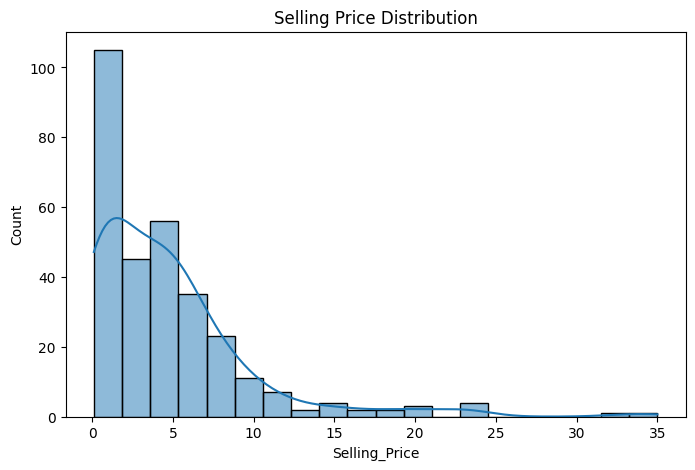

In [5]:
# Visualization for Selling Price Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['Selling_Price'], bins=20, kde=True)
plt.title("Selling Price Distribution")
plt.show()


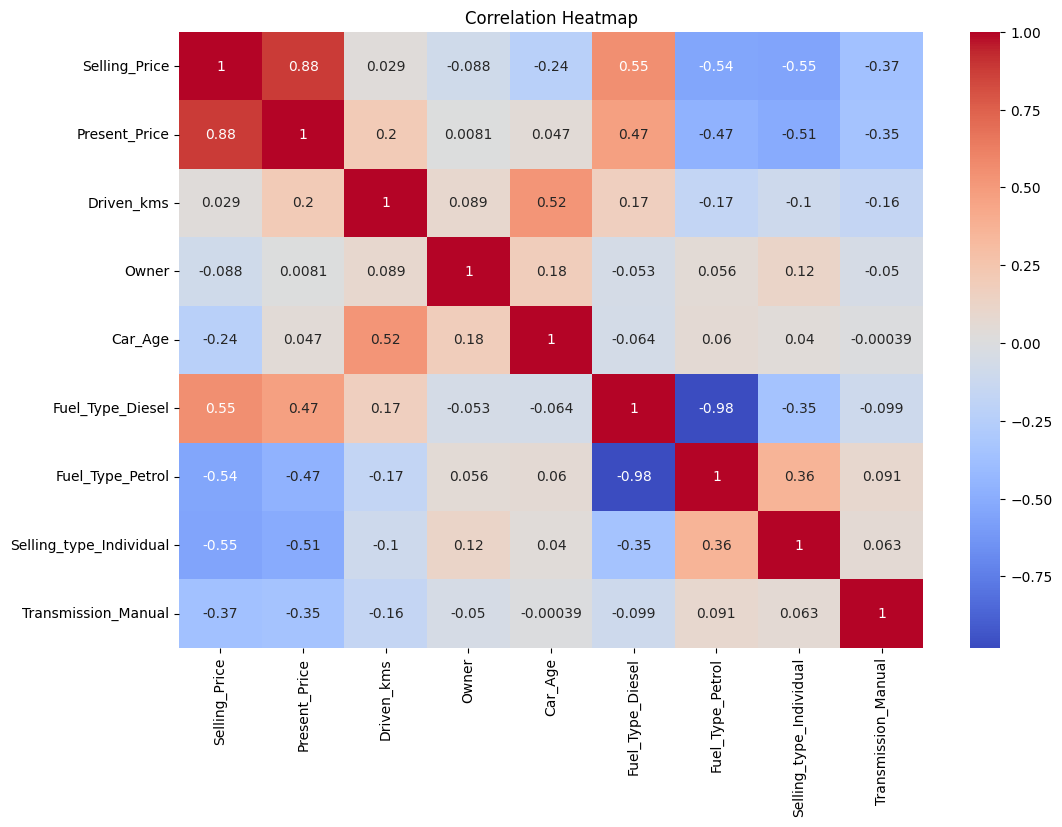

In [6]:
# Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

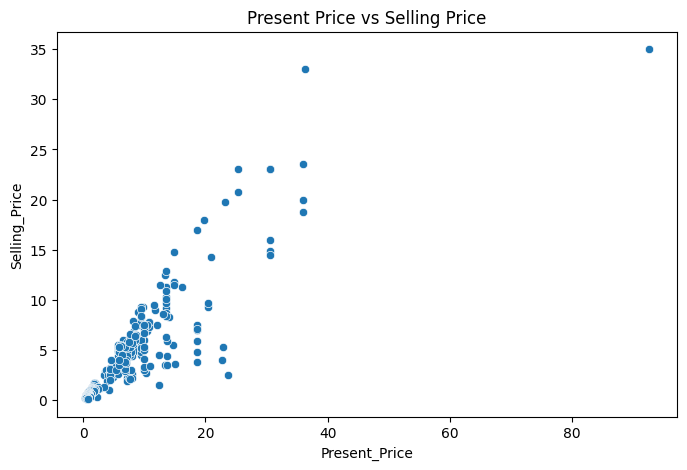

In [7]:
# Present Price vs Selling Price

plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['Present_Price'],
    y=df['Selling_Price']
)
plt.title("Present Price vs Selling Price")
plt.show()


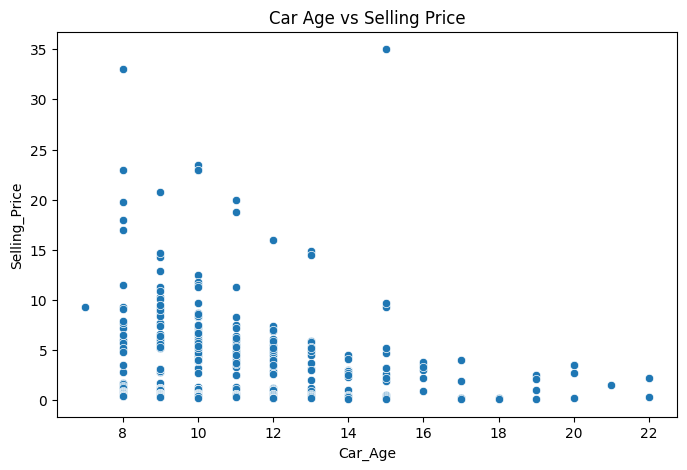

In [8]:
# Car Age vs Selling Price

plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['Car_Age'],
    y=df['Selling_Price']
)
plt.title("Car Age vs Selling Price")
plt.show()

In [9]:
# Features and Target

X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

In [10]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [11]:
# Model Training

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [12]:
# Predictions

y_pred = model.predict(X_test)

In [13]:
# Evaluation Metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("-------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


Model Performance
-------------------------
MAE : 1.2163740193330348
MSE : 3.4813498305118165
RMSE: 1.865837568094237
R2 Score: 0.8488707839193155


In [14]:
# Cross Validation

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("\nCross Validation Scores")
print(scores)

print("Mean R2 Score:", scores.mean())


Cross Validation Scores
[  0.87087237   0.78473975 -93.82163673   0.5902508    0.82659472]
Mean R2 Score: -18.149835817336477


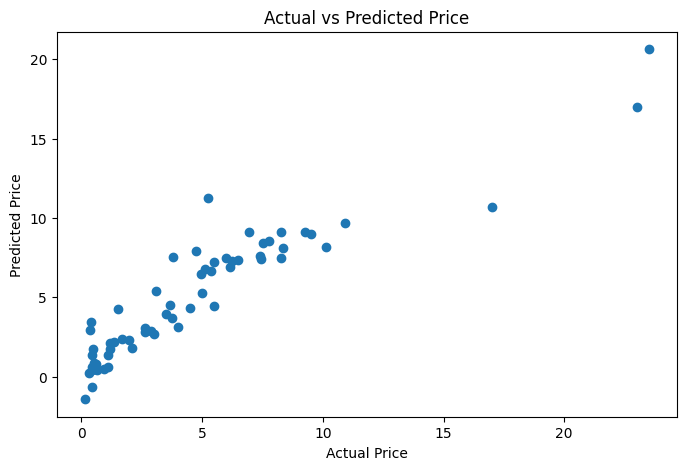

In [15]:
# Actual vs Predicted Plot

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.show()

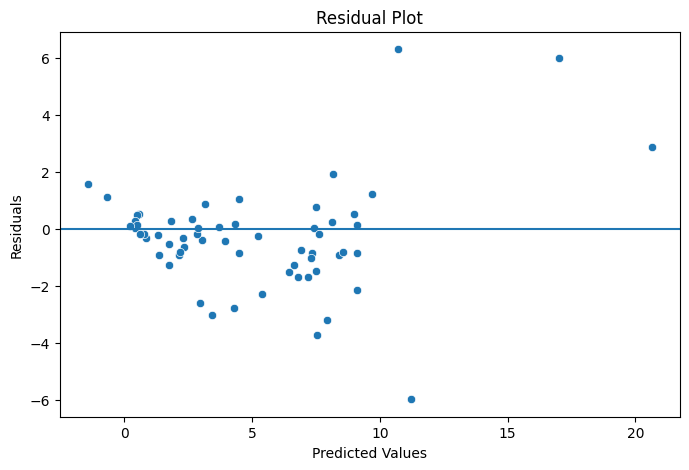

In [16]:
# Residual Plot

residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(y=0)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

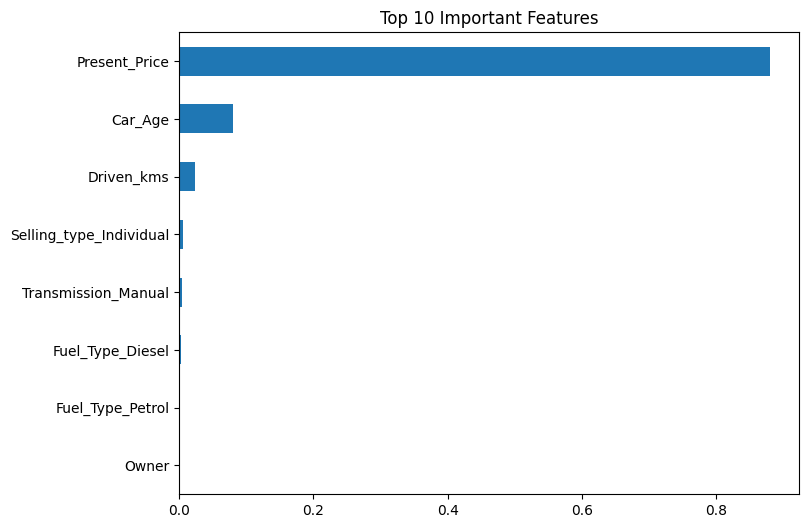

In [17]:
# Feature Importance

rf = RandomForestRegressor(random_state=42)

rf.fit(X, y)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

plt.figure(figsize=(8,6))

importance.nlargest(10).sort_values().plot(
    kind='barh'
)

plt.title("Top 10 Important Features")

plt.show()